# Common mempool subsets among nodes

## Setup

In [1]:
suppressMessages({
    require(arules, quietly=TRUE)
    require(RColorBrewer, quietly=TRUE)
    require(data.table, quietly=TRUE)
    require(ggplot2, quietly=TRUE)
    require(ggraph, quietly=TRUE)
    require(igraph, quietly=TRUE)
    require(magrittr, quietly=TRUE)
    require(tidygraph, quietly=TRUE)
})

## Read simulation results

In [2]:
fragmentation <- fread("fragmentation.tsv.gz", stringsAsFactors=TRUE)
fragmentation %>% summary

     Trial           Time [s]         Node ID               TxId          
 Min.   : 0.000   Min.   :  0.00   H102   :    13082   T305   :   453143  
 1st Qu.: 5.000   1st Qu.: 27.00   H2256  :    13082   T28    :   451584  
 Median :10.000   Median : 65.00   H2544  :    13082   T188   :   447535  
 Mean   : 9.844   Mean   : 63.85   H3831  :    13082   T261   :   436900  
 3rd Qu.:15.000   3rd Qu.: 95.00   H4651  :    13082   T48    :   435451  
 Max.   :20.000   Max.   :148.00   H5179  :    13082   T106   :   434822  
                                   (Other):130714882   (Other):128133939  

## Analyze the Dowker complex

### Randomly sample the nodes because there are too many for the method currently used below

In [3]:
theNodes <- sample(fragmentation[, unique(`Node ID`)], 200)

### Select a slice of the exerpmental data

In [4]:
theTrial <- 0

In [5]:
fragmentation[`Node ID` %in% theNodes & `Trial` == theTrial, .(`Txs`=length(unique(`TxId`))), .(`Time [s]`)]

Time [s],Txs
<int>,<int>
2,195
13,135
32,240
71,180
81,120
109,60


In [6]:
theSlot <- 13

### Format as a sparse matrix of transactions vs node mempools

In [7]:
txNodes <- as(
    split(
        fragmentation[`Node ID` %in% theNodes & `Trial` == theTrial & `Time [s]` == theSlot, `TxId`], 
        fragmentation[`Node ID` %in% theNodes & `Trial` == theTrial & `Time [s]` == theSlot, `Node ID`]
    ), 
    "transactions"
)
txNodes

transactions in sparse format with
 10000 transactions (rows) and
 135 items (columns)

### Set the smallest cluster size of interest

In [8]:
minCluster <- 2

### Set the minimum threshold for fraction of nodes containing the cluster

In [9]:
minThreshold <- 0.019

### Find the clusters

In [10]:
clusters <- eclat(
  txNodes, 
  parameter=list(
    support=minThreshold, 
    target="maximally frequent itemsets",
    minlen=minCluster
  )
)

Eclat

parameter specification:
 tidLists support minlen maxlen                      target  ext
    FALSE   0.019      2     10 maximally frequent itemsets TRUE

algorithmic control:
 sparse sort verbose
      7   -2    TRUE

Absolute minimum support count: 190 

create itemset ... 
set transactions ...[135 item(s), 10000 transaction(s)] done [0.00s].
sorting and recoding items ... [19 item(s)] done [0.00s].
creating sparse bit matrix ... [19 row(s), 10000 column(s)] done [0.00s].
writing  ... [15 set(s)] done [0.00s].
Creating S4 object  ... done [0.00s].


In [11]:
clusters %>% summary

set of 15 itemsets

most frequent items:
    T91    T351     T34     T93     T38 (Other) 
      8       5       4       4       3       6 

element (itemset/transaction) length distribution:sizes
 2 
15 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      2       2       2       2       2       2 

summary of quality measures:
    support            count      
 Min.   :0.01900   Min.   :190.0  
 1st Qu.:0.01900   1st Qu.:190.0  
 Median :0.01900   Median :190.0  
 Mean   :0.01907   Mean   :190.7  
 3rd Qu.:0.01910   3rd Qu.:191.0  
 Max.   :0.01920   Max.   :192.0  

includes transaction ID lists: FALSE 

mining info:
    data ntransactions support
 txNodes         10000   0.019
                                                                                                                         call
 eclat(data = txNodes, parameter = list(support = minThreshold, target = "maximally frequent itemsets", minlen = minCluster))

### Examine some clusters

In [12]:
barcode <- as(clusters, "data.frame") %>% as.data.table
barcode[, `Cluster size`:=size(clusters)]
barcode <- barcode[order(-`support`)]

#### Largest clusters

In [13]:
head(barcode, 10)

items,support,count,Cluster size
<chr>,<dbl>,<int>,<int>
"{T351,T91}",0.0192,192,2
"{T34,T91}",0.0192,192,2
"{T91,T93}",0.0192,192,2
"{T186,T91}",0.0191,191,2
"{T326,T91}",0.0191,191,2
"{T48,T91}",0.0191,191,2
"{T38,T91}",0.0191,191,2
"{T78,T91}",0.0190,190,2
"{T34,T48}",0.0190,190,2


#### Transactions in clusters

In [14]:
cluster1

{T78,T91} 
"{H1040,H1046,H1116,H115,H1165,H1228,H1253,H1258,H1326,H1431,H1434,H1529,H1532,H1562,H1599,H1602,H1606,H164,H1691,H1715,H1728,H1854,H187,H19,H1981,H1990,H1996,H2021,H2034,H2060,H2226,H223,H2394,H242,H2460,H2470,H2491,H2503,H2560,H2573,H2596,H2645,H2663,H2667,H2790,H281,H2869,H294,H2940,H2968,H2970,H2984,H3043,H3074,H3106,H3195,H3275,H3298,H3393,H3510,H3652,H3715,H3824,H3902,H3986,H3998,H4048,H4081,H4089,H4099,H410,H4131,H4185,H4249,H4259,H4335,H4380,H4441,H4445,H4477,H4482,H4528,H4536,H4551,H4559,H4600,H4610,H4801,H4875,H4913,H4915,H4999,H5028,H5168,H5223,H5262,H527,H5506,H5557,H562,H5661,H572,H5744,H5746,H5818,H5926,H6082,H6144,H6205,H621,H6272,H6405,H6460,H6503,H6536,H6568,H6614,H6625,H6671,H6681,H6692,H6711,H6745,H6767,H6810,H6829,H6860,H6894,H6906,H6931,H6938,H6968,H6983,H6992,H7005,H7014,H7033,H7090,H710,H7179,H7266,H7289,H7347,H7383,H7545,H7554,H7698,H7790,H7800,H7833,H7864,H7999,H8015,H8056,H8152,H8167,H8251,H8378,H8394,H8423,H8431,H8454,H8506,H8566,H8576,H8642,H8658,H8680,H8722,H8894,H8985,H8998,H9019,H910,H9114,H9124,H9137,H9193,H9218,H9263,H9266,H937,H9423,H9495,H9536,H9675,H9730,H9791,H9898,H9969}"

<font color="red">Diagnostic output</font>

In [15]:
fwrite(fragmentation[`Node ID` %in% theNodes & `Trial` == theTrial & `Time [s]` == theSlot, .(`Node ID`, `TxId`)], "diagnostics-1.tsv", sep="\t")

In [16]:
fwrite(fragmentation[`Trial` == theTrial & `Time [s]` == theSlot, .(`Node ID`, `TxId`)], "diagnostics-2.tsv", sep="\t")

### Plots

#### Barcode

In [17]:
topClusters <- head(barcode, 50)
topClusters[, `Cluster ID`:=factor(1:nrow(topClusters), levels=nrow(topClusters):1)]

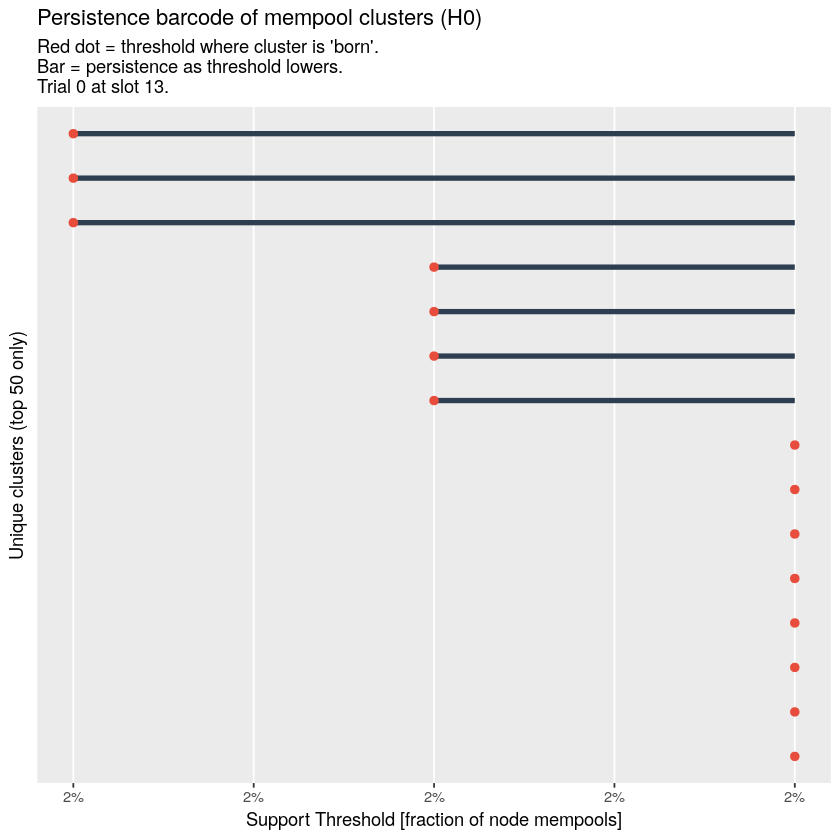

In [18]:
ggplot(topClusters, aes(y=`Cluster ID`)) +
    geom_segment(
        aes(x=`support`, xend=minThreshold, yend=`Cluster ID`), 
        linewidth = 1.5, color = "#2c3e50"
    ) +
    geom_point(aes(x=`support`), color="#e74c3c", size=2) +
    scale_x_reverse(labels=scales::percent_format(accuracy=1)) +
    labs(
        title= "Persistence barcode of mempool clusters (H0)",
        subtitle= paste0("Red dot = threshold where cluster is 'born'.\nBar = persistence as threshold lowers.\nTrial ", theTrial, " at slot ", theSlot, "."),
        x="Support Threshold [fraction of node mempools]",
        y="Unique clusters (top 50 only)"
    ) +
    theme(
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        panel.grid.major.y=element_blank(),
        panel.grid.minor.x=element_blank()
    )

In [19]:
ggsave("example-barcode.png", units="in", dpi=150, width=8, height=6)

In [20]:
ggsave("example-barcode.svg", units="in", dpi=150, width=8, height=6)

#### Cluster size vs threshold

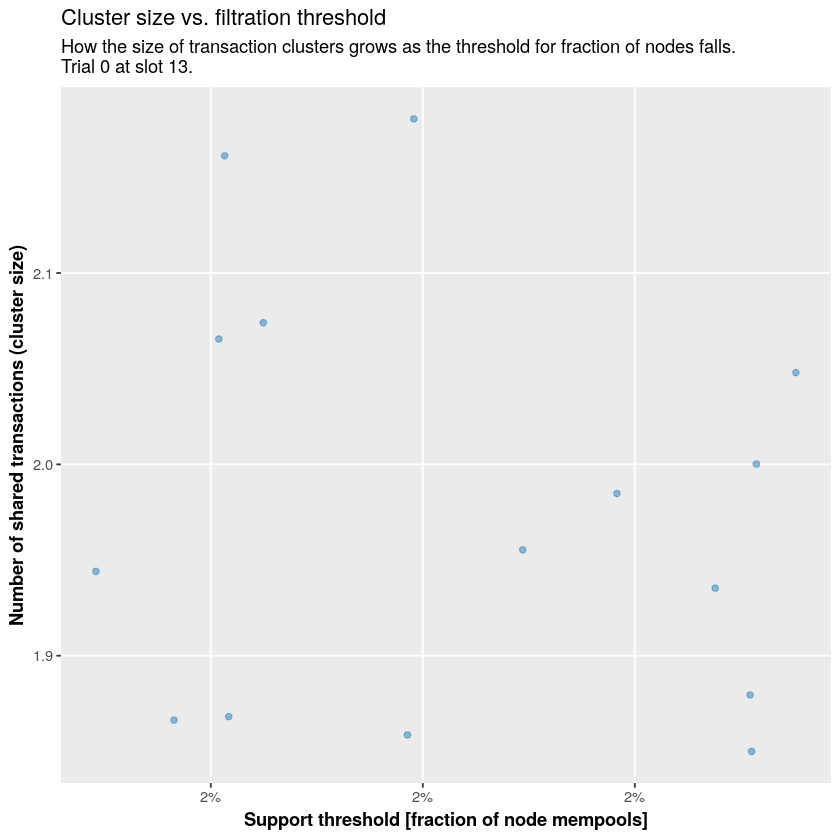

In [21]:
ggplot(barcode, aes(x=`support`, y=`Cluster size`)) +
    geom_jitter(alpha=0.5, color="#2980b9", width=0.001, height=0.2) +
    scale_x_reverse(labels=scales::percent_format(accuracy=1)) +
    labs(
        title="Cluster size vs. filtration threshold",
        subtitle=paste0("How the size of transaction clusters grows as the threshold for fraction of nodes falls.\nTrial ", theTrial, " at slot ", theSlot, "."),
        x="Support threshold [fraction of node mempools]",
        y="Number of shared transactions (cluster size)"
    ) +
    theme(
        panel.grid.minor=element_blank(),
        axis.title=element_text(face="bold")
    )

In [22]:
ggsave("example-size.png", units="in", dpi=150, width=8, height=6)

In [23]:
ggsave("example-size.svg", units="in", dpi=150, width=8, height=6)

## Compute ε-similarity

In [24]:
loads <- fragmentation[, .(`Relative load`=length(unique(`TxId`))/120), .(`Trial`, `Time [s]`)]

In [25]:
jaccard <- function(set_a, set_b) {
  inter <- length(intersect(set_a, set_b))
  union <- length(union(set_a, set_b))
  if (union == 0) return(NA_real_)
  inter / union
}

In [26]:
tx_sets <- fragmentation[, .(TxIds = list(unique(TxId))), by = .(`Trial`, `Time [s]`, `Node ID`)]

Because of the size of the dataset, we need to take a 1% sample.

In [27]:
f <- 0.025

In [28]:
similarities <- tx_sets[, {
  nodes <- `Node ID`
  n <- length(nodes)
  pairs <- CJ(i = seq_len(n), j = seq_len(n))[i < j]
  k <- max(1L, round(nrow(pairs) * f))
  pairs <- pairs[sample.int(nrow(pairs), k)]
  data.table(
    Node_A  = nodes[pairs$i],
    Node_B  = nodes[pairs$j],
    Jaccard = mapply(jaccard, TxIds[pairs$i], TxIds[pairs$j])
  )
}, by = .(Trial, `Time [s]`)]

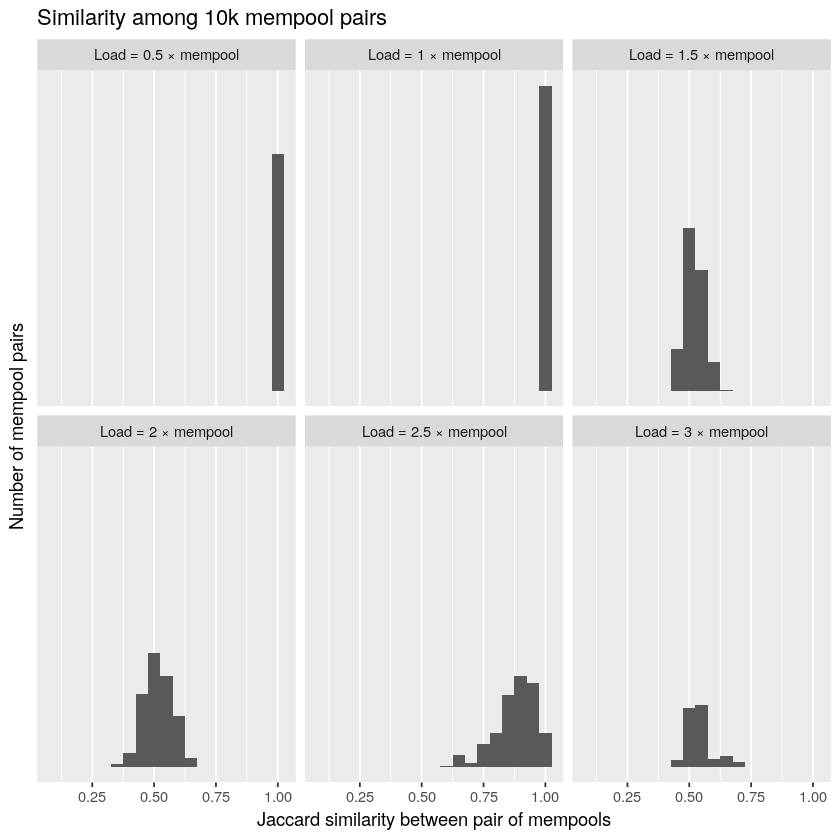

In [29]:
ggplot(
    loads[`Relative load` %in% c(0.5,1.0,1.5,2.0,2.5,3.0)][similarities, on=c("Trial", "Time [s]"), nomatch=0],
    aes(x=`Jaccard`)
) +
    geom_histogram(binwidth=0.05) +
    facet_wrap(paste("Load =", `Relative load`, "× mempool") ~ .) +
    xlab("Jaccard similarity between pair of mempools") +
    ylab("Number of mempool pairs") +
    ggtitle("Similarity among 10k mempool pairs") +
    theme(
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        panel.grid.major.y=element_blank(),
        panel.grid.minor.y=element_blank()
    )

In [30]:
ggsave("jaccard.png", units="in", dpi=150, width=8, height=6)

In [31]:
ggsave("jaccard.svg", units="in", dpi=150, width=8, height=6)

Since the computations are very slow, save the workspace for later analysis.

In [32]:
save.image(file="persistence.RData")